In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('/content/Social_Net_class.csv')

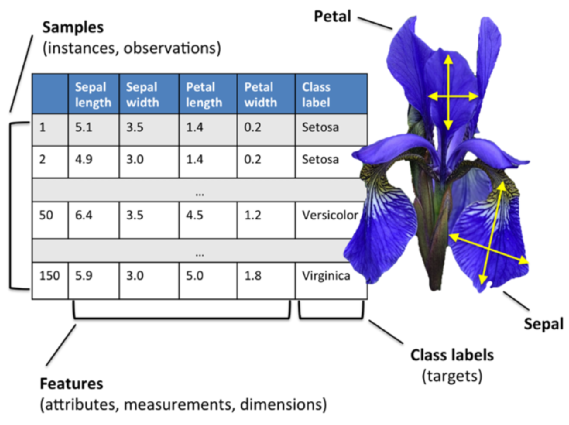

In [3]:
data.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [5]:
data[:2]

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0


In [6]:
data.values[:3] # .values convert ur df into array

array([[15624510, 'Male', 19, 19000, 0],
       [15810944, 'Male', 35, 20000, 0],
       [15668575, 'Female', 26, 43000, 0]], dtype=object)

In [7]:
X = data.iloc[:,:-1]

In [8]:
y = data.iloc[:,4]

## Split the data

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size= 0.20)

In [10]:
X_train[:3]

,User ID,Gender,Age,EstimatedSalary
312,15733964,Female,38,50000
298,15675791,Male,45,79000
386,15724150,Female,49,39000


In [11]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
User ID,400.0,1.569154e+07,71658.321581,15566689.0,15626763.75,15694341.5,15750363.0,15815236.0
Age,400.0,3.765500e+01,10.482877,18.0,29.75,37.0,46.0,60.0
EstimatedSalary,400.0,6.974250e+04,34096.960282,15000.0,43000.00,70000.0,88000.0,150000.0
Purchased,400.0,3.575000e-01,0.479864,0.0,0.00,0.0,1.0,1.0


In [12]:
from sklearn.neighbors import KNeighborsClassifier
#from sklearn.neighbors import KNeighborsRegressor

In [13]:
y.unique()

array([0, 1])

In [23]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
X_train['Gender'] = le.fit_transform(X_train['Gender'])
X_test['Gender'] = le.transform(X_test['Gender'])

In [24]:
# default value of neighbours: n_neighbors=5
knn = KNeighborsClassifier()
knn.fit(X_train,y_train)
knn.score(X_train,y_train)*100

80.3125

In [25]:
knn.score(X_test,y_test)*100

76.25

In [27]:
# TEstting phase
y_pred = knn.predict(X_test)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [28]:
# check actual and predicted result
display(y_test.values,y_pred)

array([0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0])

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [29]:
#print('Accuracy is:',model.score(X_train,y_train))#98.33
print('Accuracy is:',knn.score(X_test,y_pred))# for predicted output accuracy is always 100

Accuracy is: 1.0


Data Score- Input + Output

Model score- Actual_output + Predicted_output

In [30]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
print(confusion_matrix(y_test,y_pred))

[[47  8]
 [11 14]]


Text(50.722222222222214, 0.5, 'Actual')

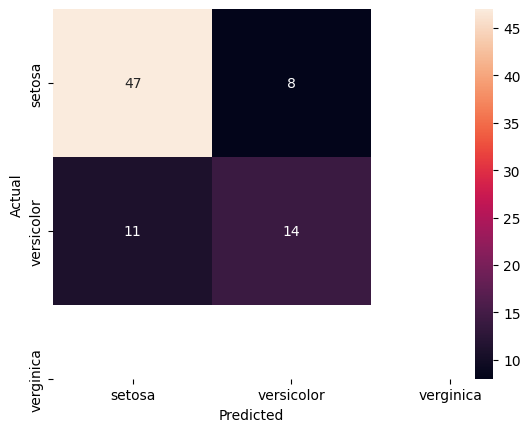

In [31]:
import seaborn as sns
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,
           xticklabels=['setosa','versicolor','verginica'],yticklabels=['setosa','versicolor','verginica'])
plt.xlabel('Predicted')
plt.ylabel('Actual')

In [32]:
# check actual records of class 0
sum(y_test == 'Iris-setosa')

0

In [33]:
#actual
sum(y_test == 'Iris-versicolor')

0

In [34]:
#predicted
sum(y_pred == 'Iris-versicolor')

np.int64(0)

In [35]:
#actual virginica
sum(y_test=='virginica')

0

In [36]:
sum(y_pred=='virginica')

np.int64(0)

In [37]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.81      0.85      0.83        55
           1       0.64      0.56      0.60        25

    accuracy                           0.76        80
   macro avg       0.72      0.71      0.71        80
weighted avg       0.76      0.76      0.76        80



In [38]:
# model's accuracy
print(accuracy_score(y_test,y_pred)*100)

76.25


# Find out value of K?

In [41]:
KNeighborsClassifier?

In [42]:
[i for i in range(1,11)]  # k value generation

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

In [43]:
from sklearn.metrics import precision_score,recall_score,f1_score

# We are going to use a precision metric as a measure for selection crieteria of K

In [44]:
for i in range(1,11):
    model = KNeighborsClassifier(n_neighbors=i)
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    print('for k value:',i,'precision is:',precision_score(y_test,y_pred,average='weighted'))

for k value: 1 precision is: 0.7450419527078566
for k value: 2 precision is: 0.7705357142857142
for k value: 3 precision is: 0.7600446428571428
for k value: 4 precision is: 0.7872023809523808
for k value: 5 precision is: 0.7559757053291535
for k value: 6 precision is: 0.8
for k value: 7 precision is: 0.7801299283154121
for k value: 8 precision is: 0.7685897435897436
for k value: 9 precision is: 0.7662231559290382
for k value: 10 precision is: 0.7685897435897436


In [45]:
from sklearn.metrics import f1_score,confusion_matrix,roc_auc_score
f1_list=[]  # list for f1_score
k_list=[] # list for K value
for k in range(1,11):
    clf=KNeighborsClassifier(n_neighbors=k,n_jobs=-1)
    clf.fit(X_train,y_train)
    pred=clf.predict(X_test)
    f=f1_score(y_test,pred,average='macro')
    f1_list.append(f)
    k_list.append(k)

In [46]:
#number of clusters
k_list

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

In [47]:
# f1_score for clusters 1-10
print(f1_list)

[0.7023809523809523, 0.6525714285714286, 0.7205368633940062, 0.7118033481669845, 0.7138015439653549, 0.7333333333333334, 0.7296760087457761, 0.7, 0.7094430992736077, 0.7]


In [48]:
max(f1_list)

0.7333333333333334

In [54]:
f1_list.index(max(f1_list))

5

In [55]:
k_list

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

In [56]:
best_f1_score=max(f1_list)
best_k=k_list[f1_list.index(best_f1_score)]
print("Optimum K value=",best_k," with F1-Score=",best_f1_score)

Optimum K value= 6  with F1-Score= 0.7333333333333334


In [57]:
scor = [0.919047619047619, 0.8754578754578755, 0.919047619047619, 0.8282828282828283, 0.9602339181286549, 0.8282828282828283, 0.919047619047619, 0.8754578754578755, 0.8754578754578755, 0.8754578754578755]
len(scor)

10

In [58]:
k_list

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

Text(0.5, 1.0, 'K neigbours vs f1_score')

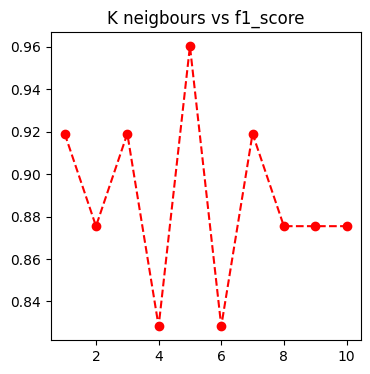

In [59]:
plt.figure(figsize=(4,4))
plt.plot(k_list,scor,'r--o')
plt.title('K neigbours vs f1_score')

Text(0.5, 1.0, 'K neigbours vs f1_score')

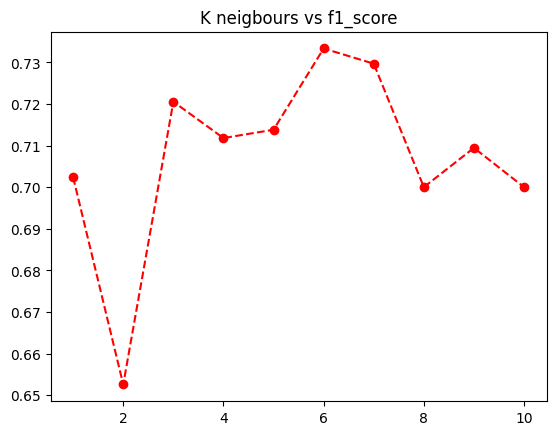

In [60]:
plt.plot(k_list,f1_list,'r--o')
plt.title('K neigbours vs f1_score')

In [61]:
from sklearn.neighbors import KNeighborsClassifier
model_2 = KNeighborsClassifier(n_neighbors=5)
model_2.fit(X_train,y_train)

KNeighborsClassifier()

In [62]:
model_2.score(X_train,y_train)*100

80.3125

# Check  K vs error rate

In [63]:
y_test.values

array([0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0])

In [64]:
y_1 = 'setosa'
pr = 'versicolor'

In [65]:
y_1 != pr

True

In [66]:
np.mean([True,False,True,False])

np.float64(0.5)

In [67]:
error_rate = []
for i in range(1,21):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

In [68]:
pred_i != y_test

,Purchased
15,False
285,True
304,False
377,False
236,False
...,...
99,False
116,False
358,True
69,False


In [69]:
print(error_rate)

[np.float64(0.25), np.float64(0.2375), np.float64(0.2375), np.float64(0.2125), np.float64(0.2375), np.float64(0.2), np.float64(0.2125), np.float64(0.225), np.float64(0.225), np.float64(0.225), np.float64(0.2125), np.float64(0.225), np.float64(0.225), np.float64(0.225), np.float64(0.225), np.float64(0.25), np.float64(0.2375), np.float64(0.25), np.float64(0.25), np.float64(0.25)]


In [70]:
k_list

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

Minimum error:- 0.2 at k = 6


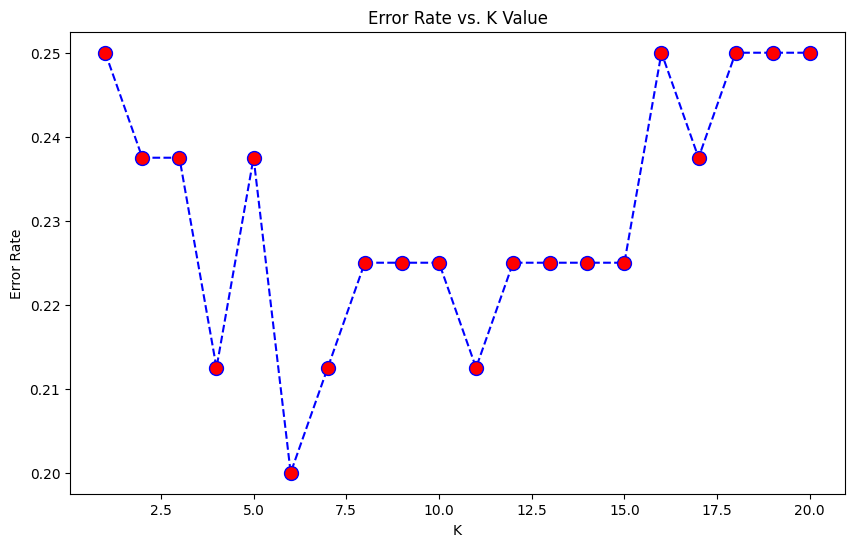

In [71]:
plt.figure(figsize=(10,6))
plt.plot(range(1,21),error_rate,color='blue', linestyle='dashed',
         marker='o',markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
print("Minimum error:-",min(error_rate),"at k =",k_list[error_rate.index(min(error_rate))])

# Find out k using precision

In [72]:
from sklearn.metrics import precision_score

In [73]:
p = []
for i in range(1,21):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    pred_i = knn.predict(X_test)
    p.append(precision_score(y_test,pred_i,average='macro'))

In [74]:
print(p)

[0.707856598016781, 0.7785714285714286, 0.7232142857142857, 0.7867965367965368, 0.7233542319749215, 0.8, 0.7643369175627239, 0.7589743589743589, 0.7497665732959851, 0.7589743589743589, 0.7734375, 0.7589743589743589, 0.7497665732959851, 0.7497665732959851, 0.7497665732959851, 0.717948717948718, 0.734375, 0.7267508610792193, 0.717948717948718, 0.7267508610792193]


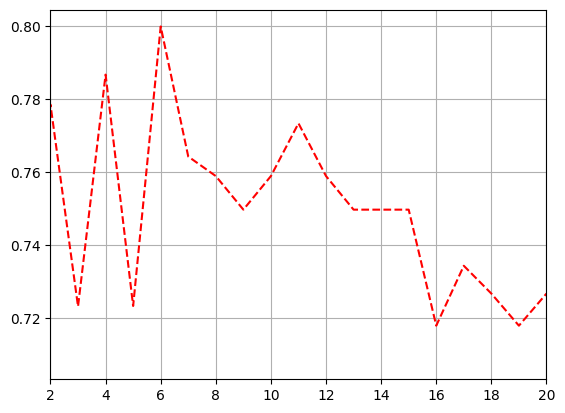

In [75]:
plt.plot(range(1,21),p,'--r')
plt.xlim((2,20))
plt.grid()

# finding the K value

In [76]:
from sklearn.neighbors import KNeighborsClassifier

In [77]:
from sklearn.metrics import recall_score

In [78]:
pr_score = []
for i in range(1,16): #k value [1-15]
    model_1 = KNeighborsClassifier(n_neighbors=i,n_jobs=-1)
    #training
    model_1.fit(X_train,y_train)
    ypred = model_1.predict(X_test)
    p_score = recall_score(y_test,ypred,average='macro')
    print('Recall for k:',i,'is:',round(p_score*100,2))
    pr_score.append(p_score)

Recall for k: 1 is: 69.82
Recall for k: 2 is: 64.18
Recall for k: 3 is: 71.82
Recall for k: 4 is: 69.27
Recall for k: 5 is: 70.73
Recall for k: 6 is: 71.27
Recall for k: 7 is: 71.45
Recall for k: 8 is: 68.36
Recall for k: 9 is: 69.45
Recall for k: 10 is: 68.36
Recall for k: 11 is: 70.36
Recall for k: 12 is: 68.36
Recall for k: 13 is: 69.45
Recall for k: 14 is: 69.45
Recall for k: 15 is: 69.45


In [79]:
print(pr_score)

[0.6981818181818182, 0.6418181818181818, 0.7181818181818181, 0.6927272727272727, 0.7072727272727273, 0.7127272727272727, 0.7145454545454546, 0.6836363636363636, 0.6945454545454546, 0.6836363636363636, 0.7036363636363636, 0.6836363636363636, 0.6945454545454546, 0.6945454545454546, 0.6945454545454546]


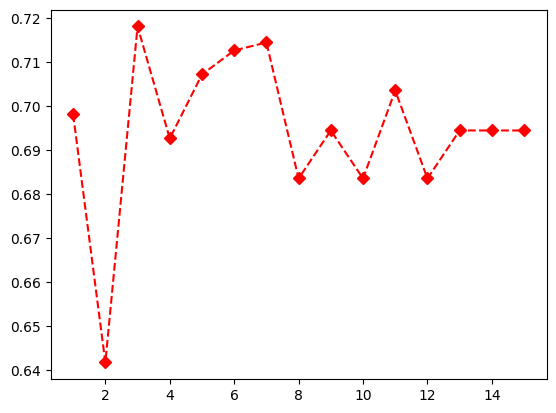

In [80]:
plt.plot(range(1,16),pr_score,'--Dr')

## Assignment: Use Social_network data and apply KNN, Find best suitable K value

In [81]:
s = pd.read_csv('Social_Net_class.csv')
s.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [82]:
s.Purchased.unique()

array([0, 1])

In [ ]:
# binary classification problem: We need to build a ML model which can predict either a person will buy or not on the
# basis of 3 features Gender Age and EstimatedSalary

In [83]:
# delete user id column
s.drop(columns=['User ID'],inplace=True)

In [84]:
# convert Gender into numbers
s['Gender'] = s['Gender'].map({'Male':0,'Female':1})

In [ ]:
s